# Library-size $\rho$ plots

This notebook makes Figures like Fig. S3: CCM skill (ρ) vs. library size, one subfigure per lag alignment, for a single (E, τ) configuration of one dyad (the default here is ALLEY00–VIEIRA11, E=4, τ=1, the same example used for Text S1.2/S1.3). Each panel plots the real relationship's convergence trajectory (Fig. 2, step 6) against the 5th–95th percentile envelope of its phase-randomized surrogate relationships, for both causal directions ("TSI influences temperature" and its reverse). Skill values are calculated from approximately 200 samplings per library size for each real relationship, and 50 samplings per library size for each of the 400 surrogate relationships. This is why the notebook builds these panels from the processed CCM output shipped with this Paleobook, rather than generating that output on the fly.

In this notebook the optimal lag for a given (E, τ) is the alignment where the real relationship pulls furthest above its surrogate envelope at the largest library sizes. `3_plot__DataGroup_lag.ipynb` then summarizes the CCM skill for the largest library size across every lag for an individual (E, τ) in one grid (Fig. S4).


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt

from cedarkit.viz.panels import LibSizeRhoPlot
from cedarkit.viz.grids import GridPlot
from cedarkit.utils.io.cloudjoblib import joblib_cloud_load
from cedarkit.core.project_config import load_config
from cedarkit.utils.cli.logging import setup_logging
from cedarkit.utils.plotting import save_figure

warnings.filterwarnings("ignore", category=FutureWarning)
notebook_name = "FigS3__libsize_lag_grid"
os.environ["CEDAR_LOG_LEVEL"] = "INFO"
setup_logging(force=True)


## Locate the bundled CCM outputs

`dyad_dir` is the directory containing the copied `tmp/` output files and
its project configuration.  The search makes the notebook runnable whether
it is launched from this notebook directory or another working directory
under the Paleobook checkout.


In [2]:
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])

proj_name = "GISP2Alley00Tanom_Vieira11TSI"
dyad_dir = stem / "hol_temp_tsi_ccm" / proj_name
tmp_dir = dyad_dir / "tmp"
config = load_config(dyad_dir / "proj_config.yaml")

figures_dir = stem / "figures" / notebook_name
figures_dir.mkdir(parents=True, exist_ok=True)

assert tmp_dir.is_dir(), f"Missing processed outputs: {tmp_dir}"
print(f"Using processed outputs in: {tmp_dir}")


Using processed outputs in: /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/GISP2Alley00Tanom_Vieira11TSI/tmp


## Load the object grid and rebase its paths

Only the `libsize_aggregated` [parquet](https://parquet.apache.org/docs/) outputs are needed for these panels — these ship pre-computed with the repository (see the book's Data & Reproducibility section), so no CCM run is required to reproduce this figure.
`resolve_paths()` handles the normal portable case.  The filename fallback
also makes a local copy take precedence when the old absolute source path is
still reachable on the machine running the notebook.


In [3]:
grid_path = tmp_dir / f"{proj_name}_obj_grid__update.joblib"
if not grid_path.exists():
    grid_path = tmp_dir / f"{proj_name}_obj_grid.joblib"
object_grid = joblib_cloud_load(grid_path)


def upgrade_legacy_grid_cell(cell_obj):
    # Older serialized GridCell objects stored one output under `output`.
    # Current GridCell exposes it through the `_outputs` backing attribute.
    if cell_obj is not None and not hasattr(cell_obj, "_outputs"):
        legacy_output = cell_obj.__dict__.pop("output", None)
        cell_obj._outputs = [] if legacy_output is None else [legacy_output]
    return cell_obj

# only necessary because project output is available outside this paleobook
def prefer_local_output_files(output_collection, local_tmp_dir):
    # resolve_paths preserves a still-valid old absolute path.  For a copied
    # Paleobook dyad, the same output filename in local tmp/ is authoritative.
    output_collection.resolve_paths(dyad_dir)
    for attr in ("table", "libsize_aggregated", "active_stats", "active_full",
                 "delta_rho_stats", "delta_rho_full"):
        output = getattr(output_collection, attr, None)
        if output is None or output.path is None:
            continue
        local_path = local_tmp_dir / Path(output.path).name
        if local_path.exists():
            output.path = local_path


object_grid_test = {}
for _, cell_obj in object_grid.items():
    cell_obj = upgrade_legacy_grid_cell(cell_obj)
    if cell_obj is None or cell_obj.output is None:
        continue
    output = cell_obj.output
    prefer_local_output_files(output, tmp_dir)
    output.set_relationships()

    E, tau = output.grp_config.E, output.grp_config.tau
    if 4 <= E <= 10 and 1 <= tau <= 8:
        object_grid_test[(E, tau)] = cell_obj

print(f"Loaded {len(object_grid_test)} grid cells: {sorted(object_grid_test)[:4]} …")


Loaded 56 grid cells: [(4, 1), (4, 2), (4, 3), (4, 4)] …


## Plot one $E, \tau$ configuration across lags

The plotter loads each selected library-size output as needed and releases it
after plotting, which keeps this multi-panel figure manageable in memory.


not heatmap []
values [-5.0, 400.0]
xlims (-5.0, 400.0) xticks [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
not plot [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
values [-5.0, 400.0]
xlims (-5.0, 400.0) xticks [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
not plot [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
values [-5.0, 400.0]
xlims (-5.0, 400.0) xticks [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
not plot [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
values [-5.0, 400.0]
xlims (-5.0, 400.0) xticks [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
not plot [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
values [-5.0, 400.0]
xlims (-5.0, 400.0) xticks [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
not plot [  0.  50. 100. 150. 200. 250. 300. 350. 400.]
Saved /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/figures/plot__DataGroup_libsize_update/libsize_lag_grid__GISP2Alley00Tanom_Vieira11TSI__E4_tau1.pdf


/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


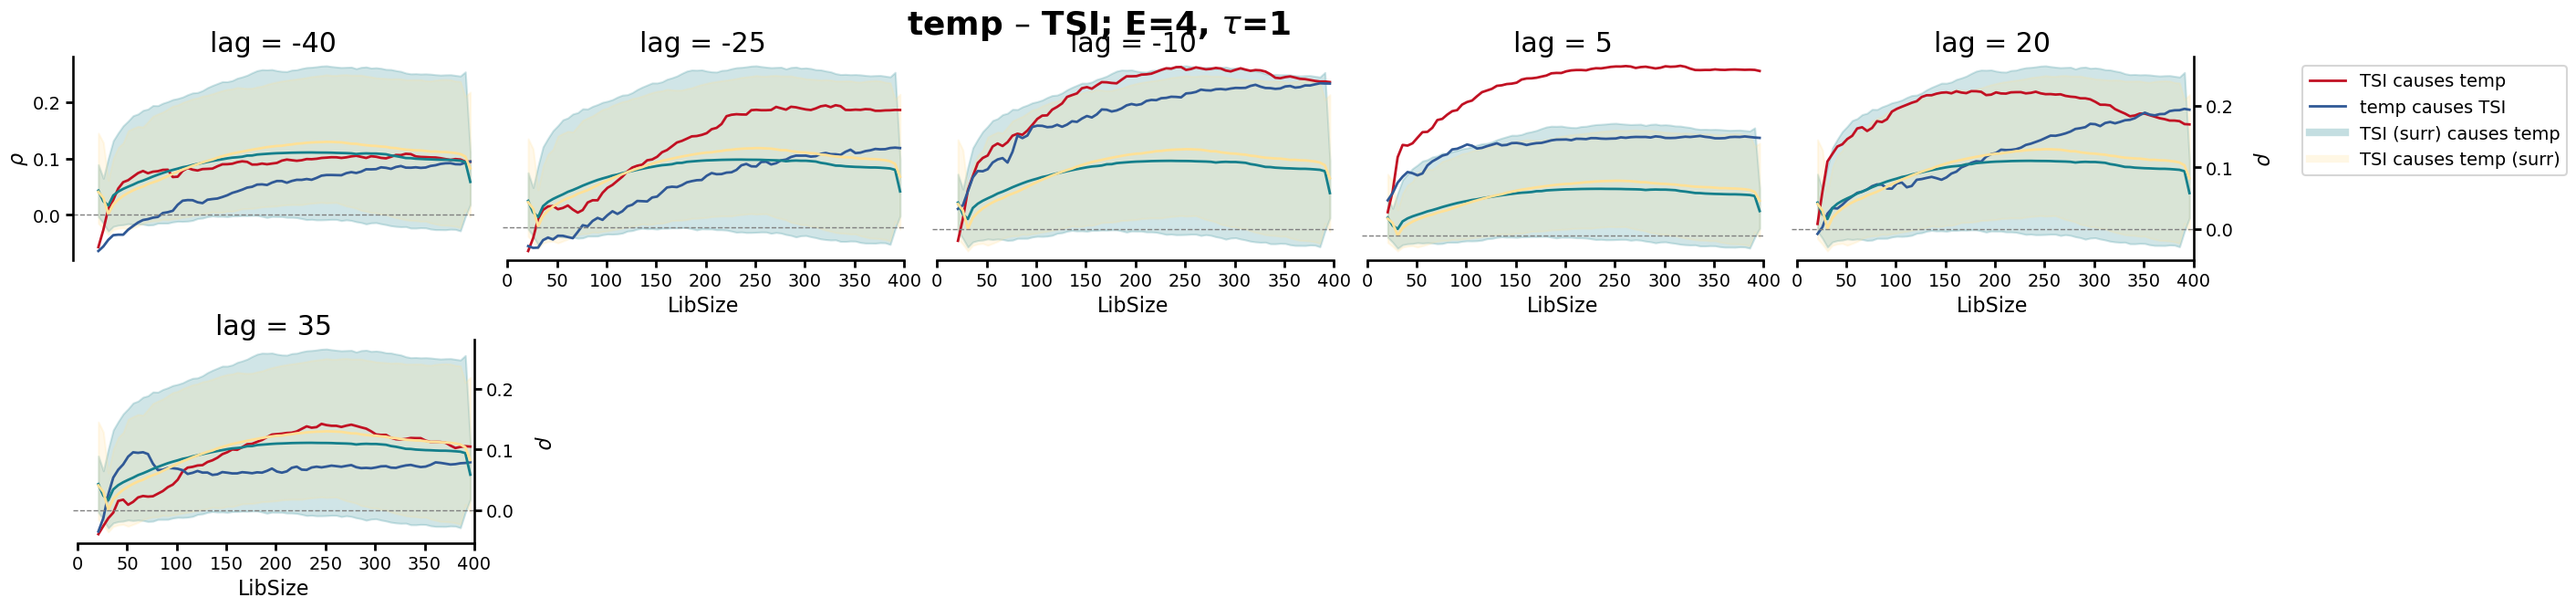

In [4]:
selected_key = (4, 1)
if selected_key not in object_grid_test:
    selected_key = sorted(object_grid_test)[0]

cell_obj = object_grid_test[selected_key]
cell_output = cell_obj.output
cell_output.set_relationships()

lag_step = 15
cols = 5
smoothed = True
selected_lags = sorted(
    cell_output.libsize_aggregated.table.select("lag").unique().collect()["lag"].to_list()
)[::lag_step]

rows = int(np.ceil(len(selected_lags) / cols))
lag_locations = {lag: divmod(index, cols) for index, lag in enumerate(selected_lags)}
var_title = f"{cell_output.grp_config.col_var} – {cell_output.grp_config.target_var}"

gridplot = GridPlot(rows, cols)
gridplot.title = f"{var_title}; E={selected_key[0]}, tau={selected_key[1]}"
gridplot.xlims = [-5, 400]
gridplot.make_grid(figsize=(6 * cols, 3 * rows), context="talk")

last_plot = None
for lag, (row, col) in lag_locations.items():
    ax = gridplot.get_ax(row, col)
    try:
        lag_plot = LibSizeRhoPlot(lag=lag, ax=ax, palette=config.pal.to_dict())
        lag_plot.relation_scope_surr = ["r1"]
        lag_plot.make_classic_plot(cell_output, smoothed=smoothed)
        lag_plot.annotations += cell_obj.annotations
        lag_plot.tidy_plot(legend=False)
        lag_plot.ax.set_title(f"lag = {lag}")
        # gridplot.ylims += [lag_plot.min_y, lag_plot.max_y]
        gridplot.add_handles_labels(lag_plot.line_handles, lag_plot.line_labels, kind="line")
        gridplot.set_ax(row, col, lag_plot.ax, entry_type="plot")
        last_plot = lag_plot
    except Exception as error:
        print(f"Could not plot lag {lag}: {error}")
        gridplot.set_ax(row, col, ax, entry_type=None)

gridplot.remove_empty()
# gridplot.ylims = [-0.1, 0.5]
gridplot.tidy_rows(add_hline=0, ylim_by="central", keep_titles="individual_normal",
                   title_pad=-8, supylabel_offset=.09, rlabel_pad=30, titley=1.03)
gridplot.add_legend(bbox_to_anchor=(1.25, 1))

# save_figure(gridplot.fig, figures_dir, stem=f"libsize_lag_grid__{proj_name}__E{selected_key[0]}_tau{selected_key[1]}", dry_run=True)


### Interpretation
All of these configurations show convergence of CCM skill as library size increases. For some lags, that skill of the real relationship does not surpass that of the surrogate envelopes, but for others it does, with an optimal lag choice at [] the alignment of the two time series yields the best performance.